## initial installing commands





In [1]:
# !pip install "alphatims[plotting]"

# !pip install hvplot

# !pip install jupyter_bokeh

# !pip install dask[dataframe]

# !pip install matplotlib

# !pip install scikit-learn

In [2]:
import alphatims.utils
import alphatims.bruker
import alphatims.plotting
import importlib
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN

from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import seaborn as sns



In [3]:


alphatims.utils.set_threads(4)
log_file_name = alphatims.utils.set_logger(
    log_file_name="tutorial_log.txt",
    overwrite=True
)

def reload():
    importlib.reload(alphatims.utils)
    importlib.reload(alphatims.bruker)
    importlib.reload(alphatims.plotting)
    alphatims.utils.set_threads(4)
    alphatims.utils.set_logger(log_file_name="tutorial_log.txt")
    
isDia = True

if (isDia):
    # bruker_d_folder_name = "../MS_Data/P4139_02_1_1_509.hdf"
    # bruker_d_folder_name = "../MS_Data/20201207_tims03_Evo03_PS_SA_HeLa_200ng_EvoSep_prot_high_speed_21min_8cm_S1-C8_1_22474.hdf"
    bruker_d_folder_name = "../MS_Data/test1.hdf"
    
else :
    bruker_d_folder_name = ""

data = alphatims.bruker.TimsTOF(bruker_d_folder_name)

2025-03-20 09:04:41> Importing data from ../MS_Data/test1.hdf
2025-03-20 09:04:41> Using HDF import for ../MS_Data/test1.hdf
2025-03-20 09:04:49> Successfully imported data from ../MS_Data/test1.hdf


## Selecting the precursor in the fist quardupole window

In [4]:
# here there are many precursors from 3 windows
m1_precursors = data[:,:,0,:]

### Extrating precursor detector events in the first Quadrupole window, for a given rt range and mobility range

In [6]:
def extractPrecursorAndFragment(quad_window_index = 1,mz_range_start=400.0,quad_window_size=25.0 ):
    # first windows index is 1
    maximum_precursor_indices = 8
    window_start_mz = mz_range_start + (quad_window_index-1)* quad_window_size
    window_end_mz = window_start_mz + quad_window_size
    # window_1_precursor = data[:,:,0,window_start_mz: window_end_mz]


    selected_mobility = 0.765332
    mobility_threshold = 0.06


    selected_rt_value = 141.751394
    rt_value_threshold = 60


    selected_fragments= data[
        selected_rt_value - rt_value_threshold/2: selected_rt_value + rt_value_threshold/2,
        selected_mobility - mobility_threshold/2: selected_mobility + mobility_threshold/2,
        ((quad_window_index -1) % maximum_precursor_indices) +1,
        :
    ]
    # following may not nesessory because of the selection use rt and mobility 
    selected_fragments = selected_fragments[selected_fragments["quad_low_mz_values"]== window_start_mz]


    selected_precursors = data[
        selected_rt_value - rt_value_threshold/2: selected_rt_value + rt_value_threshold/2,
        selected_mobility - mobility_threshold/2: selected_mobility + mobility_threshold/2,
        0,
        window_start_mz:window_end_mz
    ]

    return selected_precursors, selected_fragments


In [7]:

selected_precursors , selected_fragments = extractPrecursorAndFragment(quad_window_index=1)
selected_precursors

,raw_indices,frame_indices,scan_indices,precursor_indices,push_indices,tof_indices,rt_values,rt_values_min,mobility_values,quad_low_mz_values,quad_high_mz_values,mz_values,intensity_values,corrected_intensity_values
0,12395323,1054,753,0,978865,126673,112.158811,1.869314,0.794396,-1.0,-1.0,401.100798,52,52
1,12395324,1054,753,0,978865,126694,112.158811,1.869314,0.794396,-1.0,-1.0,401.167386,56,56
2,12395325,1054,753,0,978865,126700,112.158811,1.869314,0.794396,-1.0,-1.0,401.186412,49,49
3,12395326,1054,753,0,978865,126722,112.158811,1.869314,0.794396,-1.0,-1.0,401.256178,47,47
4,12395327,1054,753,0,978865,126813,112.158811,1.869314,0.794396,-1.0,-1.0,401.544821,131,131
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
342645,42377031,1612,805,0,1496741,132829,171.339101,2.855652,0.736273,-1.0,-1.0,420.857164,141,141
342646,42377032,1612,805,0,1496741,133036,171.339101,2.855652,0.736273,-1.0,-1.0,421.529740,95,95
342647,42377033,1612,805,0,1496741,133392,171.339101,2.855652,0.736273,-1.0,-1.0,422.687695,78,78
342648,42377034,1612,805,0,1496741,133613,171.339101,2.855652,0.736273,-1.0,-1.0,423.407337,58,58


## Peak detection 

Finding the peaks in the selected_precursors

In [9]:

# # # np.where(np.diff(np.sign(first_derivative)) < 0)[0]
# # np.percentile(sorted_selected_precursors['intensity_values'], 75)
# # # zero_crossings
# sorted_selected_precursors['mz_values']
# peaks
# np.array_equal(sorted_selected_precursors['mz_values'][peaks], selected_precursors.sort_values(by="mz_values").loc[peaks]['mz_values'] ) 
# np.array_equal(sorted_selected_precursors['mz_values'][peaks], sorted_selected_precursors.loc[peaks]['mz_values']) 


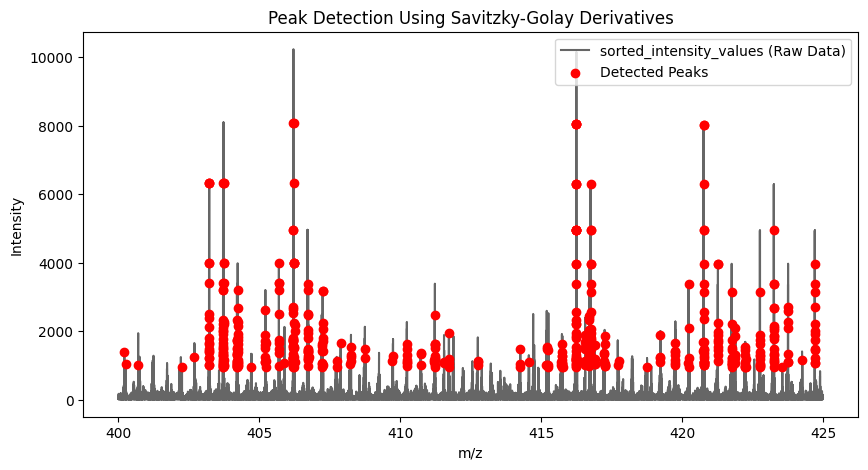

In [8]:
sorted_selected_precursors = selected_precursors.sort_values(by="mz_values")

# Apply Savitzky-Golay filter (smoothing + first derivative)
window_length = 11  # Choose based on resolution
polyorder = 3
first_derivative = savgol_filter(sorted_selected_precursors['intensity_values'], window_length, polyorder, deriv=1)
sorted_selected_precursors['first_derivation'] = savgol_filter(sorted_selected_precursors['intensity_values'], window_length, polyorder, deriv=1)

# Find zero crossings of the first derivative (peak detection)
zero_crossings = np.where(np.diff(np.sign(first_derivative)) < 0)[0]

# Filter peaks based on intensity threshold (to remove noise)
threshold = np.percentile(sorted_selected_precursors['intensity_values'], 99)  # Select peaks above 75th percentile
peaks = [i for i in zero_crossings if sorted_selected_precursors['intensity_values'][i] > threshold]

peak_df = sorted_selected_precursors.loc[peaks]

# Plot results
plt.figure(figsize=(10, 5))
plt.plot(sorted_selected_precursors['mz_values'], sorted_selected_precursors['intensity_values'], label="sorted_intensity_values (Raw Data)", color='black', alpha=0.6)
plt.scatter(peak_df['mz_values'], peak_df['intensity_values'], color='red', label="Detected Peaks", zorder=3)
plt.xlabel("m/z")
plt.ylabel("Intensity")
plt.title("Peak Detection Using Savitzky-Golay Derivatives")
plt.legend()
plt.show()


In [9]:
peak_df = peak_df.sort_values(by="intensity_values", ascending=False)
peak_df

,raw_indices,frame_indices,scan_indices,precursor_indices,push_indices,tof_indices,rt_values,rt_values_min,mobility_values,quad_low_mz_values,quad_high_mz_values,mz_values,intensity_values,corrected_intensity_values,first_derivation
17661,13453101,1081,786,0,1003954,128280,115.022336,1.917039,0.757508,-1.0,-1.0,406.212316,8082,8082,-225.929293
17908,13453890,1081,788,0,1003956,128281,115.022336,1.917039,0.755272,-1.0,-1.0,406.215507,8082,8082,20.734266
293093,37285062,1531,773,0,1421541,131408,162.744424,2.712407,0.772038,-1.0,-1.0,416.254609,8035,8035,712.202797
276468,35619253,1504,772,0,1396484,131408,159.881906,2.664698,0.773156,-1.0,-1.0,416.254609,8035,8035,466.346931
281726,36172145,1513,770,0,1404834,131408,160.836587,2.680610,0.775392,-1.0,-1.0,416.254609,8035,8035,-253.157731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88068,18626479,1198,802,0,1112546,127970,127.428142,2.123802,0.739626,-1.0,-1.0,405.223754,942,942,-123.712121
148590,23691078,1297,783,0,1204399,133107,137.925511,2.298759,0.760861,-1.0,-1.0,421.760554,942,942,-31.953186
197193,28185673,1378,757,0,1279541,130787,146.517379,2.441956,0.789924,-1.0,-1.0,414.251163,942,942,-8.993590
118926,21325518,1252,774,0,1162630,127651,133.155195,2.219253,0.770921,-1.0,-1.0,404.207749,940,940,-73.383061


In [10]:
higest_peak = peak_df.iloc[0]
higest_peak

raw_indices                   1.345310e+07
frame_indices                 1.081000e+03
scan_indices                  7.860000e+02
precursor_indices             0.000000e+00
push_indices                  1.003954e+06
tof_indices                   1.282800e+05
rt_values                     1.150223e+02
rt_values_min                 1.917039e+00
mobility_values               7.575078e-01
quad_low_mz_values           -1.000000e+00
quad_high_mz_values          -1.000000e+00
mz_values                     4.062123e+02
intensity_values              8.082000e+03
corrected_intensity_values    8.082000e+03
first_derivation             -2.259293e+02
Name: 17661, dtype: float64

### Isotopes Identification to find the Charge of precursor peptides

In [11]:
charge_1_ms_diff = 1.003
charge_2_ms_diff = 0.5015
charge_3_ms_diff = 0.3343
charge_4_ms_diff = 0.2508

In [12]:
def findAdjecentPeakForThePrecursor( index_location, peaks_in_selected_precursors, precursorDf, ms_diff ):
    # index_location = 0
    # ms_diff = charge_1_ms_diff
    selected_peak = peaks_in_selected_precursors.iloc[index_location]
    mz_value = selected_peak['mz_values']
    intensity_value = selected_peak['intensity_values']
    filtered_raws_1 = precursorDf[precursorDf['mz_values']== mz_value]
    # filtered_raws_1
    isotop_arr = []
    for i in range(7):
        error_tolerance = 0.01
        filtered_raws_1 = precursorDf[(precursorDf['mz_values'] >= mz_value + (i-3)*ms_diff - error_tolerance) & ( precursorDf['mz_values'] <= mz_value + (i-3)*ms_diff+error_tolerance)]
        # filtered_raws_1 = precursorDf[precursorDf['mz_values']== mz_value + (i-3)*ms_diff]
        isotop_arr.append(not filtered_raws_1.empty)
    return isotop_arr


In [ ]:
# index_location = 0
# ms_diff = charge_1_ms_diff
# selected_peak = peaks_in_selected_precursors.iloc[index_location]
# mz_value = selected_peak['mz_values']
# intensity_value = selected_peak['intensity_values']
# filtered_raws_1 = selected_precursors[selected_precursors['mz_values']== mz_value]
# filtered_raws_1
# isotop_arr = []
# for i in range(7):
#     filtered_raws_1 = selected_precursors[selected_precursors['mz_values']== mz_value + (i-3)*ms_diff]
#     isotop_arr.append(not filtered_raws_1.empty)
# isotop_arr

charge_ms_diff = {
    1: 1.003,
    2: 0.5015,
    3: 0.3343,
    4: 0.2508
}
precursor_charges = []

for i in range(100):
    best_charge = None
    for key, val in charge_ms_diff.items():
        isotop_arr = findAdjecentPeakForThePrecursor( 
            index_location = i, 
            peaks_in_selected_precursors=peak_df, 
            precursorDf=sorted_selected_precursors,
            ms_diff= val )
        if (False in isotop_arr):
            print(key, val)
            print(isotop_arr)
        # if any(isotop_arr):
        #     print(key, val)
        #     print(isotop_arr)
        
        # print(isotop_arr)
        if False not in isotop_arr:  
            best_charge = key  # Assign charge if all isotopic peaks are found
            break  # Stop checking once a valid charge is found

    if best_charge:
        precursor_charges[i] = best_charge  # Store detected charge
        print(f"Precursor {i} has charge: {best_charge}")
    else:
        print(f"Precursor {i} has no valid charge detected.")
    

## consider the distrubution of the adjesent to peaks



In [46]:
# filtered_raws_2 = selected_precursors[selected_precursors['mz_values'] == mz_value + charge_2_ms_diff ]
# filtered_raws_2
len(peak_df)

492

### Peak findings

In [ ]:
# peaks,_ = find_peaks(selected_precursors['intensity_values'], height=200)

# # peaks, _ = find_peaks(selected_precursors['intensity_values'], distance=20)
# peaks2, _ = find_peaks(selected_precursors['intensity_values'], prominence=1)
# # BEST!
# peaks3, _ = find_peaks(selected_precursors['intensity_values'], width=20)
# peaks4, _ = find_peaks(selected_precursors['intensity_values'], threshold=0.4) 

# len(selected_precursors['mz_values'].iloc[peaks])

33

In [21]:
# plt.subplot(2, 2, 1)
# plt.plot(filtered_precursor.iloc[peaks]['intensity_values'], "xr"); 
# plt.plot(filtered_precursor['intensity_values']); plt.legend(['distance'])

# plt.subplot(2, 2, 2)
# plt.plot(peaks2, filtered_precursor.iloc[peaks2]['intensity_values'], "ob"); 
# plt.plot(filtered_precursor['intensity_values']); plt.legend(['prominence'])

# plt.subplot(2, 2, 3)
# plt.plot(peaks3, filtered_precursor.iloc[peaks3]['intensity_values'], "vg"); 
# plt.plot(filtered_precursor['intensity_values']); plt.legend(['width'])

# plt.subplot(2, 2, 4)
# plt.plot(peaks4, filtered_precursor.iloc[peaks4]['intensity_values'], "xk"); 
# plt.plot(filtered_precursor['intensity_values']); plt.legend(['threshold'])
# plt.show()

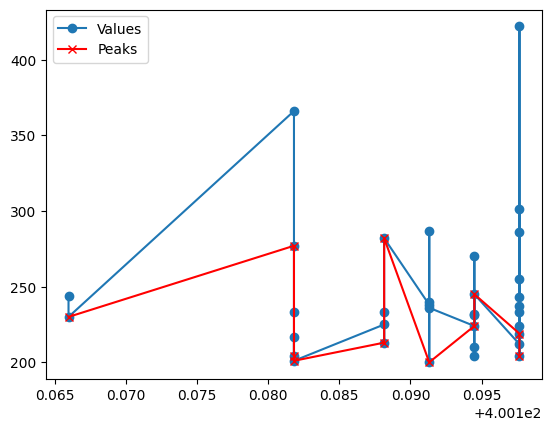

In [57]:
sorted_indices = filtered_precursor['mz_values'].sort_values().index
sorted_mz_values = filtered_precursor.loc[sorted_indices, 'mz_values'].values
sorted_intensity_values = filtered_precursor.loc[sorted_indices, 'intensity_values'].values

# Plot the entire spectrum
plt.plot(sorted_mz_values, sorted_intensity_values, marker='o', label="Values")

# Plot the peaks in red
plt.plot(sorted_mz_values[peaks], sorted_intensity_values[peaks], color='red', marker='x', label="Peaks")


plt.legend()
plt.show()


In [ ]:
# from scipy.signal import savgol_filter

# # Example m/z and intensity data (Replace with real data)
# mz = np.linspace(100, 1000, 900)  # Simulated m/z values
# intensity = np.exp(-((mz - 400) ** 2) / (2 * 50 ** 2)) * 100 + \
#             np.exp(-((mz - 700) ** 2) / (2 * 30 ** 2)) * 80 + \
#             np.random.normal(0, 2, len(mz))  # Simulated peaks + noise



Resolution Type	Recommended Window Length


High-resolution MS (Orbitrap, FT-ICR)	7–15

Medium-resolution MS (TOF, Q-TOF)	11–21

Low-resolution MS (quadrupole, ion trap)	15–25

In [59]:
sorted_indices = selected_precursors['mz_values'].sort_values().index
sorted_mz_values = selected_precursors.loc[sorted_indices, 'mz_values'].values
sorted_intensity_values = selected_precursors.loc[sorted_indices, 'intensity_values'].values

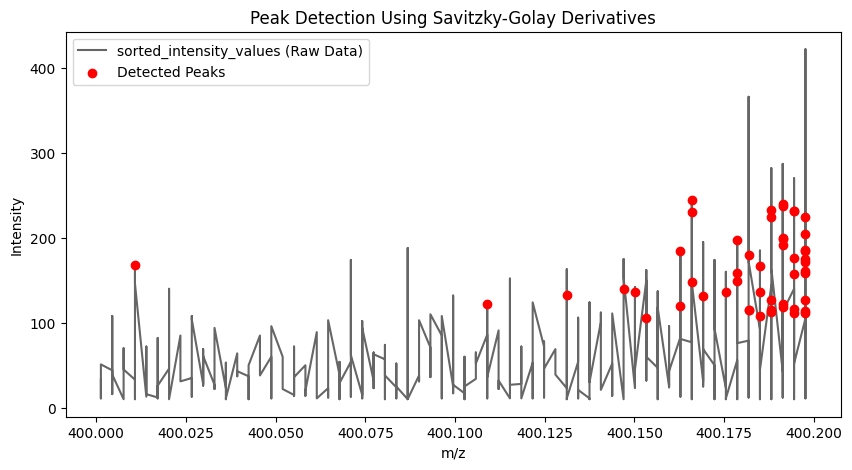

In [60]:

# Apply Savitzky-Golay filter (smoothing + first derivative)
window_length = 11  # Choose based on resolution
polyorder = 3
first_derivative = savgol_filter(sorted_intensity_values, window_length, polyorder, deriv=1)

# Find zero crossings of the first derivative (peak detection)
zero_crossings = np.where(np.diff(np.sign(first_derivative)) < 0)[0]

# Filter peaks based on intensity threshold (to remove noise)
threshold = np.percentile(sorted_intensity_values, 75)  # Select peaks above 75th percentile
peaks = [i for i in zero_crossings if sorted_intensity_values[i] > threshold]

# Plot results
plt.figure(figsize=(10, 5))
plt.plot(sorted_mz_values, sorted_intensity_values, label="sorted_intensity_values (Raw Data)", color='black', alpha=0.6)
plt.scatter(sorted_mz_values[peaks], sorted_intensity_values[peaks], color='red', label="Detected Peaks", zorder=3)
plt.xlabel("m/z")
plt.ylabel("Intensity")
plt.title("Peak Detection Using Savitzky-Golay Derivatives")
plt.legend()
plt.show()


In [62]:
original_peak_indices  = sorted_indices[peaks]
peaks_in_selected_precursors = selected_precursors.loc[original_peak_indices]
peaks_in_selected_precursors

,raw_indices,frame_indices,scan_indices,precursor_indices,push_indices,tof_indices,rt_values,rt_values_min,mobility_values,quad_low_mz_values,quad_high_mz_values,mz_values,intensity_values,corrected_intensity_values
1027,42355484,1612,759,0,1496695,126329,171.339101,2.855652,0.787688,-1.0,-1.0,400.010815,168,168
1031,42371327,1612,790,0,1496726,126360,171.339101,2.855652,0.753037,-1.0,-1.0,400.108979,122,122
738,31309363,1432,781,0,1329677,126367,152.242287,2.537371,0.763096,-1.0,-1.0,400.131147,133,133
933,37853249,1540,800,0,1429920,126372,163.698955,2.728316,0.741861,-1.0,-1.0,400.146981,140,140
841,34537974,1486,805,0,1379813,126373,157.972676,2.632878,0.736273,-1.0,-1.0,400.150148,136,136
426,20851058,1243,757,0,1154261,126374,132.199740,2.203329,0.789924,-1.0,-1.0,400.153315,106,106
411,20398451,1234,771,0,1145923,126377,131.245796,2.187430,0.774274,-1.0,-1.0,400.162816,120,120
360,19046568,1207,773,0,1120869,126377,128.384181,2.139736,0.772038,-1.0,-1.0,400.162816,184,184
938,38414008,1549,798,0,1438270,126378,164.652197,2.744203,0.744096,-1.0,-1.0,400.165983,244,244
1021,41798887,1603,784,0,1488368,126378,170.379339,2.839656,0.759743,-1.0,-1.0,400.165983,230,230


In [ ]:
def group_isotopes_optimized(df, mz_tolerance=0.02, rt_tolerance=0.3, mobility_tolerance=0.01):
    min_values = df.min()
    max_values = df.max()
    
    rt_min_value = min_values['rt_values']
    rt_max_value = max_values['rt_values']
    
    mobility_min_value = min_values['mobility_values']
    mobility_max_value = max_values['mobility_values']
    
    mz_min_values = min_values['mz_values']
    mz_max_values = max_values['mz_values']
    
    
    df = df.sort_values(by=["rt_values"]).reset_index(drop=True)
    rt_bins = np.arange(rt_min_value, rt_max_value + rt_tolerance, rt_tolerance)
    df["rt_group"] = pd.cut(df["rt_values"], rt_bins,  labels=rt_bins[:-1])
    
    
    df = df.sort_values(by=["mobility_values"]).reset_index(drop=True)
    mobility_bins = np.arange(mobility_min_value, mobility_max_value + mobility_tolerance, mobility_tolerance)
    df["mobility_group"] = pd.cut(df["mobility_values"], mobility_bins,  labels=mobility_bins[:-1])
    
    
    df = df.sort_values(by=["mz_values"]).reset_index(drop=True)
    mobility_bins = np.arange(mz_min_values, mz_max_values +mz_tolerance, mz_tolerance)
    df["mz_group"] = pd.cut(df["mz_values"], mobility_bins,  labels=mobility_bins[:-1])
    
    

    # grouped_sets = set(df.groupby(["rt_group", "mobility_group", "mz_group"]).groups.keys())
    df["peptide_group"] = df.groupby(["rt_group", "mobility_group", "mz_group"]).ngroup()


    
    return df
    
    


# # Group isotopes (FAST!)
# isotope_groups = group_isotopes_optimized(window_1_precursor)

# # Print grouped isotope sets
# for idx, group in enumerate(isotope_groups):
#     print(f"Isotope Group {idx + 1}:")
#     print(group, "\n")


### Finding out the eg rt and mobility value to continue with the selection of similar Precursor and fragments to consider

To proceed with the selection of appropriate precursors and fragments, it is essential to determine the values of eg, rt, and mobility. These parameters will serve as the foundation for identifying and evaluating similar candidates, ensuring a systematic and informed approach to the selection process.

In [11]:
window_1_precursor_rt = window_1_precursor['rt_values']
window_1_precursor_rt.value_counts()

import matplotlib.pyplot as plt

window_1_precursor_rt.value_counts().plot(kind="bar")
plt.xlabel("Categories")
plt.ylabel("Count")
plt.title("Bar Chart of Column Data")
plt.xticks(rotation=90)  # Rotate labels 90 degrees
# plt.yscale("log")
plt.show()

# here are the values couunt of rt values of all the precursors in the 1st quadrupole windows
window_1_precursor_rt.value_counts()

NameError: name 'window_1_precursor' is not defined

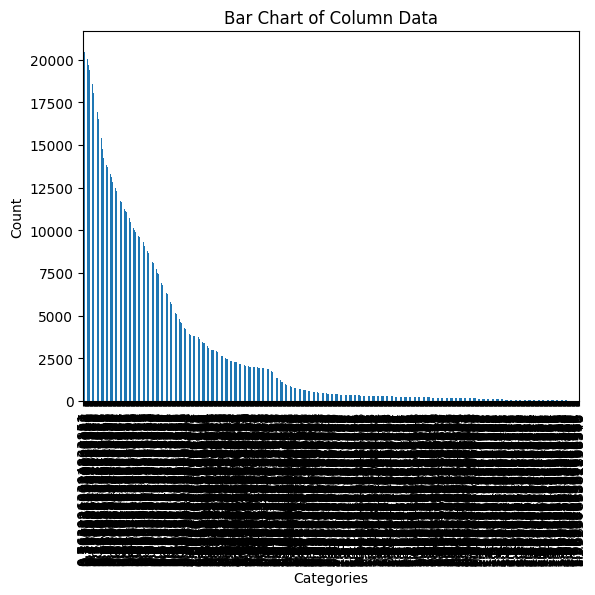

mobility_values
0.763096    20618
0.764214    20499
0.765332    20422
0.760861    20320
0.759743    20231
            ...  
1.598127        2
1.584640        2
1.586887        1
1.592507        1
1.585764        1
Name: count, Length: 884, dtype: int64

In [43]:
window_1_precursor_mobility = window_1_precursor['mobility_values']
window_1_precursor_mobility.value_counts()

import matplotlib.pyplot as plt

window_1_precursor_mobility.value_counts().plot(kind="bar")
plt.xlabel("Categories")
plt.ylabel("Count")
plt.title("Bar Chart of Column Data")
plt.xticks(rotation=90)  # Rotate labels 90 degrees
# plt.yscale("log")
plt.show()

# here are the values couunt of rt values of all the precursors in the 1st quadrupole windows
window_1_precursor_mobility.value_counts()

### Extracting Fragments of the Window 1 precursors

In [ ]:
quad_low_mz_value = 400.0
selected_precursor_mobility = 0.765332
mobility_threshold = 0.06


selected_precursor_rt_value = 141.751394
rt_value_threshold = 60


precurser_index_1_fragments= data[
    selected_precursor_rt_value - rt_value_threshold: selected_precursor_rt_value + rt_value_threshold,
    selected_precursor_mobility - mobility_threshold: selected_precursor_mobility + mobility_threshold,
    1,
    :]

window_1_fragments = precurser_index_1_fragments[precurser_index_1_fragments["quad_low_mz_values"]== quad_low_mz_value]
# window_1_fragments.sort_values(by="intensity_values",ascending= False)
window_1_fragments

window_1_fragments = data[:,:,1,]

Selecting the fragment related to the quadrupole window

In [3]:
window_1_fragments= data[:,:,1,:]   #data.__getitem__((slice(None), slice(None), 2, slice(None)))
quad_low_mz_values = window_1_fragments['quad_low_mz_values'].unique()
quad_high_mz_values = window_1_fragments['quad_high_mz_values'].unique()
print(quad_high_mz_values,quad_low_mz_values)

# i= 0
# window_1_precursor = window_1_precursor[(precursor_temp['mz_values']>=quad_low_mz_values[2-i]) & (precursor_temp['mz_values']<quad_high_mz_values[2-i])]
# window_1_precursor


[825. 625. 425.] [800. 600. 400.]


In [14]:
import numpy as np
import pandas as pd


# finding the similar raws with the selected thresholds 
def group_similar_rows(df, rt_tolerance, mobility_tolerance, mz_tolerance):
    min_values = df.min()
    max_values = df.max()
    
    rt_min_value = min_values['rt_values']
    rt_max_value = max_values['rt_values']
    
    mobility_min_value = min_values['mobility_values']
    mobility_max_value = max_values['mobility_values']
    
    mz_min_values = min_values['mz_values']
    mz_max_values = max_values['mz_values']
    
    
    df = df.sort_values(by=["rt_values"]).reset_index(drop=True)
    rt_bins = np.arange(rt_min_value, rt_max_value + rt_tolerance, rt_tolerance)
    df["rt_group"] = pd.cut(df["rt_values"], rt_bins,  labels=rt_bins[:-1])
    
    
    df = df.sort_values(by=["mobility_values"]).reset_index(drop=True)
    mobility_bins = np.arange(mobility_min_value, mobility_max_value + mobility_tolerance, mobility_tolerance)
    df["mobility_group"] = pd.cut(df["mobility_values"], mobility_bins,  labels=mobility_bins[:-1])
    
    
    df = df.sort_values(by=["mz_values"]).reset_index(drop=True)
    mobility_bins = np.arange(mz_min_values, mz_max_values +mz_tolerance, mz_tolerance)
    df["mz_group"] = pd.cut(df["mz_values"], mobility_bins,  labels=mobility_bins[:-1])
    
    

    grouped_df = df.groupby(["rt_group", "mobility_group", "mz_group"], observed=True).agg({
        "rt_values": "mean",
        "mobility_values": "mean",
        "mz_values": "mean",
        "intensity_values": "sum"
    }).reset_index(drop=True)
    
    


    return grouped_df

In [10]:
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

def group_isotopes_optimized(df, mz_tolerance=0.02, rt_tolerance=0.3, mobility_tolerance=0.01):
    min_values = df.min()
    max_values = df.max()
    
    rt_min_value = min_values['rt_values']
    rt_max_value = max_values['rt_values']
    
    mobility_min_value = min_values['mobility_values']
    mobility_max_value = max_values['mobility_values']
    
    mz_min_values = min_values['mz_values']
    mz_max_values = max_values['mz_values']
    
    
    df = df.sort_values(by=["rt_values"]).reset_index(drop=True)
    rt_bins = np.arange(rt_min_value, rt_max_value + rt_tolerance, rt_tolerance)
    df["rt_group"] = pd.cut(df["rt_values"], rt_bins,  labels=rt_bins[:-1])
    
    
    df = df.sort_values(by=["mobility_values"]).reset_index(drop=True)
    mobility_bins = np.arange(mobility_min_value, mobility_max_value + mobility_tolerance, mobility_tolerance)
    df["mobility_group"] = pd.cut(df["mobility_values"], mobility_bins,  labels=mobility_bins[:-1])
    
    
    df = df.sort_values(by=["mz_values"]).reset_index(drop=True)
    mobility_bins = np.arange(mz_min_values, mz_max_values +mz_tolerance, mz_tolerance)
    df["mz_group"] = pd.cut(df["mz_values"], mobility_bins,  labels=mobility_bins[:-1])
    
    

    # grouped_sets = set(df.groupby(["rt_group", "mobility_group", "mz_group"]).groups.keys())
    df["peptide_group"] = df.groupby(["rt_group", "mobility_group", "mz_group"]).ngroup()


    
    return df
    
    


# Group isotopes (FAST!)
isotope_groups = group_isotopes_optimized(window_1_precursor)

# # Print grouped isotope sets
# for idx, group in enumerate(isotope_groups):
#     print(f"Isotope Group {idx + 1}:")
#     print(group, "\n")


C:\Users\havin\AppData\Local\Temp\ipykernel_23856\3369013978.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["peptide_group"] = df.groupby(["rt_group", "mobility_group", "mz_group"]).ngroup()


In [11]:
# for idx, group in enumerate(isotope_groups):
#     print(f"Isotope Group {idx + 1}:")
#     print(group, "\n")
#     break
isotope_groups[isotope_groups['peptide_group'].isnull()]

,raw_indices,frame_indices,scan_indices,precursor_indices,push_indices,tof_indices,rt_values,rt_values_min,mobility_values,quad_low_mz_values,quad_high_mz_values,mz_values,intensity_values,corrected_intensity_values,rt_group,mobility_group,mz_group,peptide_group
0,98648221,2566,786,0,2382034,126326,272.495279,4.541588,0.757508,-1.0,-1.0,400.001315,64,64,272.30466,0.751114,NaN,NaN
1,2612288,172,665,0,160281,126326,18.635681,0.310595,0.892809,-1.0,-1.0,400.001315,164,164,18.50466,0.891114,NaN,NaN
2,40079098,1576,753,0,1463281,126326,167.514939,2.791916,0.794396,-1.0,-1.0,400.001315,28,28,167.30466,0.791114,NaN,NaN
3,55143363,1810,784,0,1680464,126326,192.326686,3.205445,0.759743,-1.0,-1.0,400.001315,70,70,192.20466,0.751114,NaN,NaN
4,5470583,739,698,0,686490,126326,78.754222,1.312570,0.855896,-1.0,-1.0,400.001315,102,102,78.50466,0.851114,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2539410,722218,1,823,0,1751,134101,0.504660,0.008411,0.716159,-1.0,-1.0,424.998579,97,97,NaN,0.711114,424.981315,NaN
2539428,427704,1,642,0,1570,134101,0.504660,0.008411,0.918541,-1.0,-1.0,424.998579,57,57,NaN,0.911114,424.981315,NaN
2539435,538497,1,700,0,1628,134101,0.504660,0.008411,0.853660,-1.0,-1.0,424.998579,44,44,NaN,0.851114,424.981315,NaN
2539438,714904,1,813,0,1741,134101,0.504660,0.008411,0.727333,-1.0,-1.0,424.998579,93,93,NaN,0.721114,424.981315,NaN


In [15]:
grouped_window_1_precursors =  group_similar_rows(
    window_1_precursor, 
    rt_tolerance= 60, 
    mobility_tolerance=0.06, 
    mz_tolerance= 0.1
    ).sort_values(by="intensity_values",ascending= False)


# this contains the peptide detector events in the selected quadropole window
# grouped_window_1_precursors.sort_values(by="mobility_values",ascending= False)
grouped_window_1_precursors.sort_values(by="mz_values")


,rt_values,mobility_values,mz_values,intensity_values
11780,291.581747,0.659184,400.018731,342
18151,333.568242,1.388091,400.020314,10
1856,16.725823,1.123438,400.020314,10
4334,61.579239,1.129040,400.020314,67
2205,37.718847,1.427380,400.026647,95
...,...,...,...,...
4333,101.341621,1.051749,424.975733,367
4719,102.612299,1.157054,424.978997,31
11208,207.595348,1.241689,424.982261,141
10796,223.339735,1.121197,424.987156,228


In [16]:
# These selected_precursor_mobility and selected_precursor_rt_value are needed
# to find the fragment detector events
quad_low_mz_value = 400.0
selected_precursor_mobility = 0.760861
mobility_threshold = 0.001


selected_precursor_rt_value = 115.976836
rt_value_threshold = 1


precurser_index_1_fragments= data[
    selected_precursor_rt_value - rt_value_threshold: selected_precursor_rt_value + rt_value_threshold,
    selected_precursor_mobility - mobility_threshold: selected_precursor_mobility + mobility_threshold,
    1,
    :]

window_1_fragments = precurser_index_1_fragments[precurser_index_1_fragments["quad_low_mz_values"]== quad_low_mz_value]
# window_1_fragments.sort_values(by="intensity_values",ascending= False)
window_1_fragments



,raw_indices,frame_indices,scan_indices,precursor_indices,push_indices,tof_indices,rt_values,rt_values_min,mobility_values,quad_low_mz_values,quad_high_mz_values,mz_values,intensity_values,corrected_intensity_values
0,13491887,1082,783,1,1004879,56361,115.127354,1.918789,0.760861,400.0,425.0,209.138559,137,137
1,13491888,1082,783,1,1004879,56416,115.127354,1.918789,0.760861,400.0,425.0,209.264506,12,12
2,13491889,1082,783,1,1004879,58963,115.127354,1.918789,0.760861,400.0,425.0,215.138490,297,297
3,13491890,1082,783,1,1004879,64048,115.127354,1.918789,0.760861,400.0,425.0,227.108869,128,128
4,13491891,1082,783,1,1004879,70266,115.127354,1.918789,0.760861,400.0,425.0,242.186765,77,77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
573,13852971,1091,783,1,1013231,226356,116.081472,1.934691,0.760861,400.0,425.0,779.430151,32,32
574,13852972,1091,783,1,1013231,231083,116.081472,1.934691,0.760861,400.0,425.0,800.463238,181,181
575,13852973,1091,783,1,1013231,235290,116.081472,1.934691,0.760861,400.0,425.0,819.418068,83,83
576,13852974,1091,783,1,1013231,246363,116.081472,1.934691,0.760861,400.0,425.0,870.368176,86,86


In [17]:
window_1_fragments[["mz_values","intensity_values"]].sort_values(by="mz_values")

,mz_values,intensity_values
310,191.069635,98
311,195.071175,157
0,209.138559,137
1,209.264506,12
2,215.138490,297
...,...,...
308,812.449279,112
575,819.418068,83
576,870.368176,86
577,929.513519,172


In [18]:
amino_acid_masses_acid_to_weight = {
    'Ala': 71,  # Alanine
    'Arg': 156,  # Arginine
    'Asn': 114,  # Asparagine
    'Asp': 115,  # Aspartic acid
    'Cys': 103,  # Cysteine
    'Gln': 128,  # Glutamine
    'Glu': 129,  # Glutamic acid
    'Gly': 57,   # Glycine
    'His': 137,  # Histidine
    'Ile': 113,  # Isoleucine
    'Leu': 113,  # Leucine
    'Lys': 128,  # Lysine
    'Met': 131,  # Methionine
    'Phe': 147,  # Phenylalanine
    'Pro': 97,   # Proline
    'Ser': 87,   # Serine
    'Thr': 101,  # Threonine
    'Trp': 186,  # Tryptophan
    'Tyr': 163,  # Tyrosine
    'Val': 99    # Valine
}


amino_acid_masses_weigth_to_acid = {
    57: 'Gly',   # Glycine
    71: 'Ala',   # Alanine
    87: 'Ser',   # Serine
    97: 'Pro',   # Proline
    99: 'Val',   # Valine
    101: 'Thr',  # Threonine
    103: 'Cys',  # Cysteine
    113: ['Leu','Ile'],  # Leucine, Isoleucine
    114: 'Asn',  # Asparagine
    115: 'Asp',  # Aspartic acid
    128: 'Lys',  # Lysine
    128: 'Gln',  # Glutamine
    129: 'Glu',  # Glutamic acid
    131: 'Met',  # Methionine
    137: 'His',  # Histidine
    147: 'Phe',  # Phenylalanine
    156: 'Arg',  # Arginine
    163: 'Tyr',  # Tyrosine
    186: 'Trp',  # Tryptophan
}


In [19]:
# finding the precursor mass
precursor_mz = 413.053060
precursor_charge = 2
precursor_mass = precursor_mz * precursor_charge - precursor_charge

In [21]:
def check_key_within_threshold(my_dict, key, threshold):
    for k in my_dict:
        if abs(k - key) <= threshold:
            return True
    
    return False


def get_values_within_threshold(my_dict, key, threshold):
    values_within_threshold = []
    
    # Iterate through all keys in the dictionary
    for k in my_dict:
        # Check if the absolute difference between key k and the given key is within the threshold
        if abs(k - key) <= threshold:
            # If within the threshold, append the corresponding value to the result list
            values_within_threshold.append(my_dict[k])
    
    return values_within_threshold


In [22]:
# here we get the fragments whose mass is less than the precursor mass
# fragment charge is considered as 1.
# So mz values is equals to its mass

fragement_temp = window_1_fragments[["mz_values","intensity_values"]][window_1_fragments["mz_values"]<precursor_mass].sort_values(by="mz_values",ascending=False)

valid_fragment_indices ={
    # key = raw index, 
    # value  = 
}

for index, row in fragement_temp.iterrows():
    mass = row["mz_values"]
    intensity = row["intensity_values"]
    # print(f"Mass: {mass}, Intensity: {intensity}")
    
    
    y_ion_mass = mass
    b_ion_mass = precursor_mass - y_ion_mass
    mass_threshold = 1
    
    print(f"y_ion_mass: {y_ion_mass}, b_ion_mass: {b_ion_mass}")
    
    # if( b_ion_mass in amino_acid_masses_weigth_to_acid ): #need to add the threshold
    if( check_key_within_threshold(amino_acid_masses_weigth_to_acid, b_ion_mass, mass_threshold)): #need to add the threshold
        print(b_ion_mass, ' is in ')
        break
           

fragement_temp

y_ion_mass: 819.418067559946, b_ion_mass: 4.68805244005398
y_ion_mass: 812.4492788863289, b_ion_mass: 11.656841113671135
y_ion_mass: 800.4632381441517, b_ion_mass: 23.642881855848373
y_ion_mass: 791.3606877865024, b_ion_mass: 32.74543221349768
y_ion_mass: 788.4017862738398, b_ion_mass: 35.70433372616026
y_ion_mass: 781.4380965663366, b_ion_mass: 42.66802343366339
y_ion_mass: 779.4301505864703, b_ion_mass: 44.67596941352974
y_ion_mass: 760.3918148083048, b_ion_mass: 63.71430519169519
y_ion_mass: 759.3793261678526, b_ion_mass: 64.72679383214745
y_ion_mass: 755.3970334664481, b_ion_mass: 68.70908653355195
y_ion_mass: 751.9677846147264, b_ion_mass: 72.13833538527365
y_ion_mass: 749.3998842700523, b_ion_mass: 74.70623572994771
y_ion_mass: 749.2915391873315, b_ion_mass: 74.81458081266851
y_ion_mass: 748.4553787891796, b_ion_mass: 75.65074121082046
y_ion_mass: 746.447038095736, b_ion_mass: 77.65908190426399
y_ion_mass: 746.447038095736, b_ion_mass: 77.65908190426399
y_ion_mass: 745.4438795506

,mz_values,intensity_values
575,819.418068,83
308,812.449279,112
574,800.463238,181
307,791.360688,67
306,788.401786,212
...,...,...
2,215.138490,297
1,209.264506,12
0,209.138559,137
311,195.071175,157


In [23]:
import numpy as np
import pandas as pd

quad_mz_min_value = 200
quad_mz_max_value = 1200


def quantize_mz_and_sum_intensity(df, mz_min, mz_max, bin_width):
    # Define m/z bin edges
    bins = np.arange(mz_min, mz_max + bin_width, bin_width)
    # print((bins))


    df["mz_bin"] = pd.cut(df["mz_values"], bins, right=False, labels=bins[:-1])
    # print(df.groupby("mz_bin", observed=True))

    # Compute weighted sum of intensities for each bin
    grouped_df = df.groupby("mz_bin")["intensity_values"].sum().reset_index()

    return grouped_df

bin_width = 5 # Define bin width

result_df = quantize_mz_and_sum_intensity(window_1_fragments, quad_mz_min_value, quad_mz_max_value, bin_width)
print(result_df)


    mz_bin  intensity_values
0      200                 0
1      205               149
2      210                 0
3      215               430
4      220               148
..     ...               ...
195   1175                 0
196   1180                 0
197   1185                 0
198   1190                 0
199   1195                 0

[200 rows x 2 columns]


C:\Users\havin\AppData\Local\Temp\ipykernel_23856\3316685338.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_df = df.groupby("mz_bin")["intensity_values"].sum().reset_index()


grouping MS1 detector events by similar rows


In [62]:
# import pandas as pd
# import numpy as np

# # Load data (assuming you already have a DataFrame named df)
# # Define similarity thresholds
# rt_tolerance = 1e-3  # Adjust based on precision needed
# mobility_tolerance = 1e-3
# mz_tolerance = 1e-2

# # Sort values to ensure similar ones are adjacent
# df = window_1_precursor.sort_values(by=["rt_values"])

# # Group similar rows
# def group_similar_rows(df):
#     grouped_data = []
#     current_group = [df.iloc[0]]

#     for i in range(1, len(df)):
#         prev = current_group[-1]
#         curr = df.iloc[i]

#         if (
#             abs(prev["rt_values"] - curr["rt_values"]) < rt_tolerance and
#             abs(prev["mobility_values"] - curr["mobility_values"]) < mobility_tolerance and
#             abs(prev["mz_values"] - curr["mz_values"]) < mz_tolerance
#         ):
#             current_group.append(curr)
#         else:
#             # Aggregate and save the group
#             merged_row = merge_rows(current_group)
#             grouped_data.append(merged_row)
#             current_group = [curr]

#     # Process last group
#     if current_group:
#         grouped_data.append(merge_rows(current_group))

#     return pd.DataFrame(grouped_data)

# # Function to merge a group of similar rows
# def merge_rows(group):
#     merged = group[0].copy()
#     merged["intensity_values"] = sum(row["intensity_values"] for row in group)
#     merged["corrected_intensity_values"] = sum(row["corrected_intensity_values"] for row in group)
#     return merged

# # Apply grouping
# filtered_df = group_similar_rows(df)

# # Display the final dataset
# print(filtered_df)


In [ ]:
# import numpy as np

# frame_indices = alphatims.bruker.convert_slice_key_to_int_array(data, slice(0,10000), "frame_indices")
# scan_indices = alphatims.bruker.convert_slice_key_to_int_array(data, slice(0,500000), "scan_indices")
# precursor_indices = np.array([[0, 1, 1]])
# tof_indices = alphatims.bruker.convert_slice_key_to_int_array(data, slice(0,500000), "tof_indices")
# quad_values = np.array([[-1, 0]])
# intensity_slices = np.arange(0, 1000)


# intensity_values = alphatims.bruker.convert_slice_key_to_float_array(
#                         slice(0,1000)
#                     )

            
# elected_indices = alphatims.bruker.filter_indices(
#                         frame_slices=frame_indices,
#                         scan_slices=scan_indices,
#                         precursor_slices= precursor_indices,
#                         tof_slices=tof_indices,
#                         quad_slices=quad_values,
#                         intensity_slices=intensity_values,
#                         frame_max_index=data.frame_max_index,
#                         scan_max_index=data.scan_max_index,
#                         push_indptr=data.push_indptr,
#                         precursor_indices=data.precursor_indices,
#                         quad_mz_values=data.quad_mz_values,
#                         quad_indptr=data.quad_indptr,
#                         tof_indices=data.tof_indices,
#                         intensities=data.intensity_values
#                     )

# elected_events = data.as_dataframe(
#     elected_indices
# )
# elected_events

array([        0,         1,         2, ..., 126975384, 126975385,
       126975386])

Using np grouping

In [ ]:
import pandas as pd

data_range = 77042361 
chunk_size = 7704236  # Number of rows per chunk




# Iterate through the DataFrame in chunks
for i in range(0, data_range, chunk_size):  # Use 'data_range' instead of 'range'
    chunk = precursor_temp.iloc[i:i + chunk_size]
    temp_df = chunk.groupby(
        ["frame_indices", "scan_indices","precursor_indices","quad_low_mz_values"]
        ).agg({
        "raw_indices": list,
        "push_indices": "first",
        "tof_indices": "first",
        "rt_values": "first",
        "rt_values_min": "first",
        "mobility_values": list,
        "quad_high_mz_values": "first",
        "mz_values": "first",
        "intensity_values": "sum"
    }).reset_index()
    print(temp_df)
    

In [ ]:

    
final_df = precursor_temp.head(100).groupby(
    ["frame_indices", "scan_indices","precursor_indices","quad_low_mz_values"]
    ).agg({
    "raw_indices": list,
    "push_indices": "first",
    "tof_indices": "first",
    "rt_values": "first",
    "rt_values_min": "first",
    "mobility_values": "first",
    "quad_high_mz_values": "first",
    "mz_values": "first",
    "intensity_values": "sum"
}).reset_index()

# final_df
# Merge back with the original DataFrame to keep all columns (other fields)
final_df = pd.merge(precursor_temp, final_df, on=["frame_indices", "scan_indices","precursor_indices","quad_low_mz_values"], how='left')

In [ ]:
total = 0
for i in range(len(final_df["raw_indices"])):
    total += len(final_df['raw_indices'][i])
    
total

In [ ]:
precursor_temp["intensity_values"]

0            10
1            74
2            35
3           101
4            55
           ... 
77042357    124
77042358    132
77042359     58
77042360     89
77042361    106
Name: intensity_values, Length: 77042362, dtype: uint16

In [19]:
precursor_temp.head()

,raw_indices,frame_indices,scan_indices,precursor_indices,push_indices,tof_indices,rt_values,rt_values_min,mobility_values,quad_low_mz_values,quad_high_mz_values,mz_values,intensity_values,corrected_intensity_values
0,0,1,44,0,972,92735,0.50466,0.008411,1.589135,-1.0,-1.0,300.710089,10,10
1,1,1,45,0,973,281963,0.50466,0.008411,1.588011,-1.0,-1.0,1044.585829,74,74
2,2,1,46,0,974,265013,0.50466,0.008411,1.586887,-1.0,-1.0,959.655833,35,35
3,3,1,47,0,975,239005,0.50466,0.008411,1.585764,-1.0,-1.0,836.340583,101,101
4,4,1,49,0,977,291253,0.50466,0.008411,1.583516,-1.0,-1.0,1092.662003,55,55


In [16]:
precursor_temp['frame_indices'].unique()

array([   1,    4,    5, ..., 3174, 3175, 3176])

In [ ]:

# List to store new rows
new_rows = []

# Process each group
for _, group in grouped:
    # Check if mz_values are within the threshold
    mz_values = group['mz_values'].values
    intensity_values = group['intensity_values'].values

    # If mz_values are within the threshold, combine them
    if np.ptp(mz_values) <= mz_threshold:  # ptp is peak-to-peak (max - min)
        # Linear interpolation to get a representative m/z value (e.g., the average)
        interpolated_mz = np.mean(mz_values)
        
        # Sum the intensities
        total_intensity = np.sum(intensity_values)
        
        # Create a new row with combined information
        new_row = {
            'frame_indices': group['frame_indices'].iloc[0],
            'scan_indices': group['scan_indices'].iloc[0],
            'precursor_indices': group['precursor_indices'].iloc[0],
            'quad_low_mz_values': group['quad_low_mz_values'].iloc[0],
            'mz_values': interpolated_mz,  # representative m/z value
            'intensity_values': total_intensity  # summed intensity
        }
        
        # Append the new row to the list
        new_rows.append(new_row)

# Create a DataFrame from the new rows
final_df = pd.DataFrame(new_rows)

print(final_df)


In [28]:
def inspect_peptide(
    dia_data,
    peptide,
    ppm=50,
    rt_tolerance=30, #seconds
    mobility_tolerance=0.05, #1/k0
    heatmap=False
):
    precursor_mz = peptide["mz"]
    precursor_mobility = peptide["mobility"]
    precursor_rt = peptide["rt"]
    fragment_mzs = peptide["fragment_mzs"]
    rt_slice = slice(
        precursor_rt - rt_tolerance,
        precursor_rt + rt_tolerance
    )
    im_slice = slice(
        precursor_mobility - mobility_tolerance,
        precursor_mobility + mobility_tolerance
    )
    precursor_mz_slice = slice(
        precursor_mz / (1 + ppm / 10**6),
        precursor_mz * (1 + ppm / 10**6)
    )
    precursor_indices = dia_data[
        rt_slice,
        im_slice,
        0, #index 0 means that the quadrupole is not used
        precursor_mz_slice,
        "raw"
    ]
    if heatmap:
        precursor_heatmap = alphatims.plotting.heatmap(
            dia_data.as_dataframe(precursor_indices),
            x_axis_label="rt",
            y_axis_label="mobility",
            title="precursor",
            width=250,
            height=250
        )
        overlay = precursor_heatmap
    else:
        precursor_xic = alphatims.plotting.line_plot(
            dia_data,
            precursor_indices,
            x_axis_label="rt",
            width=900,
            remove_zeros=True,
            label="precursor"
        )
        overlay = precursor_xic
    for fragment_name, mz in fragment_mzs.items():
        fragment_mz_slice = slice(
            mz / (1 + ppm / 10**6),
            mz * (1 + ppm / 10**6)
        )
        fragment_indices = dia_data[
            rt_slice,
            im_slice,
            precursor_mz_slice,
            fragment_mz_slice,
            "raw"
        ]
        if len(fragment_indices) > 0:
            if heatmap:
                fragment_heatmap = alphatims.plotting.heatmap(
                    dia_data.as_dataframe(fragment_indices),
                    x_axis_label="rt",
                    y_axis_label="mobility",
                    title=f"{fragment_name}: {mz:.3f}",
                    width=250,
                    height=250,
                )
                overlay += fragment_heatmap
            else:
                fragment_xic = alphatims.plotting.line_plot(
                    dia_data,
                    fragment_indices,
                    x_axis_label="rt",
                    width=900,
                    remove_zeros=True,
                    label=fragment_name,
                )
                overlay *= fragment_xic.opts(muted=True)
    if not heatmap:
        overlay.opts(hv.opts.Overlay(legend_position='bottom'))
        overlay.opts(hv.opts.Overlay(click_policy='mute'))
        overlay = overlay.opts(show_legend=True)
        hv.save(overlay, "tutorial_dia_xic_overlay.html")
    return overlay.opts(
        title=f"{peptide['sequence']}_{peptide['charge']}"
    )